# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


## last Five row

In [4]:
df.tail()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
4995,42,Female,15.3,2,1,1,92,292,121,0,1,1,0,0,0,100.0
4996,39,Female,24.2,0,1,1,140,156,83,0,0,0,0,0,0,100.0
4997,48,Female,19.2,2,0,0,135,247,89,1,1,1,0,0,0,100.0
4998,34,Male,24.0,0,1,1,144,254,187,1,1,1,0,0,0,100.0
4999,72,Female,29.9,1,0,1,115,179,121,1,0,0,1,1,1,100.0


## Shape of our dataset

In [5]:
df.shape

(5000, 16)

## List out all columns

In [6]:
df.columns

Index(['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol',
       'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain',
       'dizziness', 'heart_disease', 'diabetes', 'stroke',
       'health_risk_score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

age                    int64
gender                object
bmi                  float64
exercise_level         int64
smoking                int64
alcohol                int64
blood_pressure         int64
cholesterol            int64
glucose                int64
fatigue                int64
chest_pain             int64
dizziness              int64
heart_disease          int64
diabetes               int64
stroke                 int64
health_risk_score    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   bmi                5000 non-null   float64
 3   exercise_level     5000 non-null   int64  
 4   smoking            5000 non-null   int64  
 5   alcohol            5000 non-null   int64  
 6   blood_pressure     5000 non-null   int64  
 7   cholesterol        5000 non-null   int64  
 8   glucose            5000 non-null   int64  
 9   fatigue            5000 non-null   int64  
 10  chest_pain         5000 non-null   int64  
 11  dizziness          5000 non-null   int64  
 12  heart_disease      5000 non-null   int64  
 13  diabetes           5000 non-null   int64  
 14  stroke             5000 non-null   int64  
 15  health_risk_score  5000 non-null   float64
dtypes: float64(2), int64(13)

## Check Null Value

In [9]:
df.isnull().sum()

age                  0
gender               0
bmi                  0
exercise_level       0
smoking              0
alcohol              0
blood_pressure       0
cholesterol          0
glucose              0
fatigue              0
chest_pain           0
dizziness            0
heart_disease        0
diabetes             0
stroke               0
health_risk_score    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

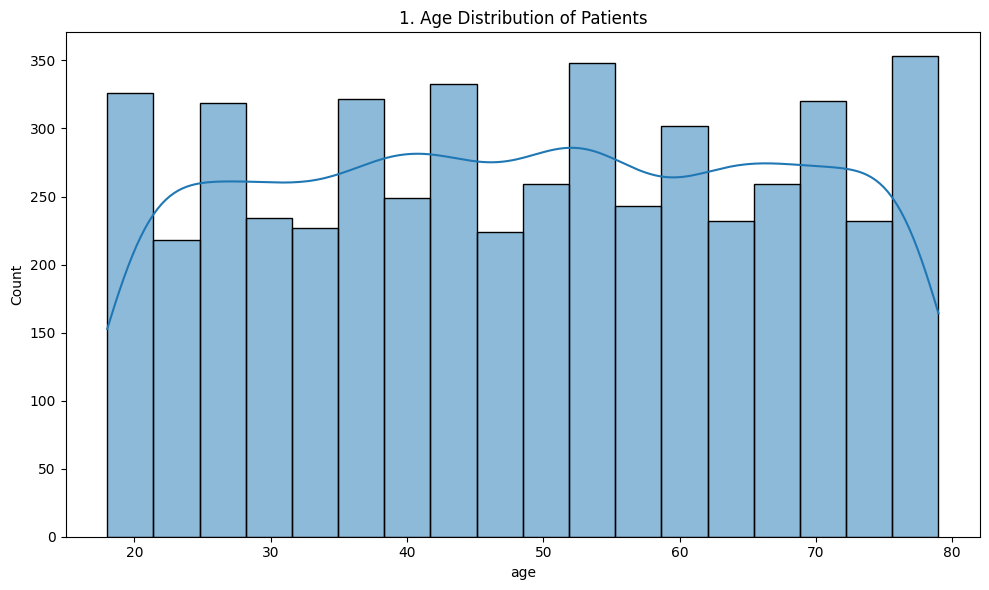

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Patients')
show_fig()
plot_no += 1

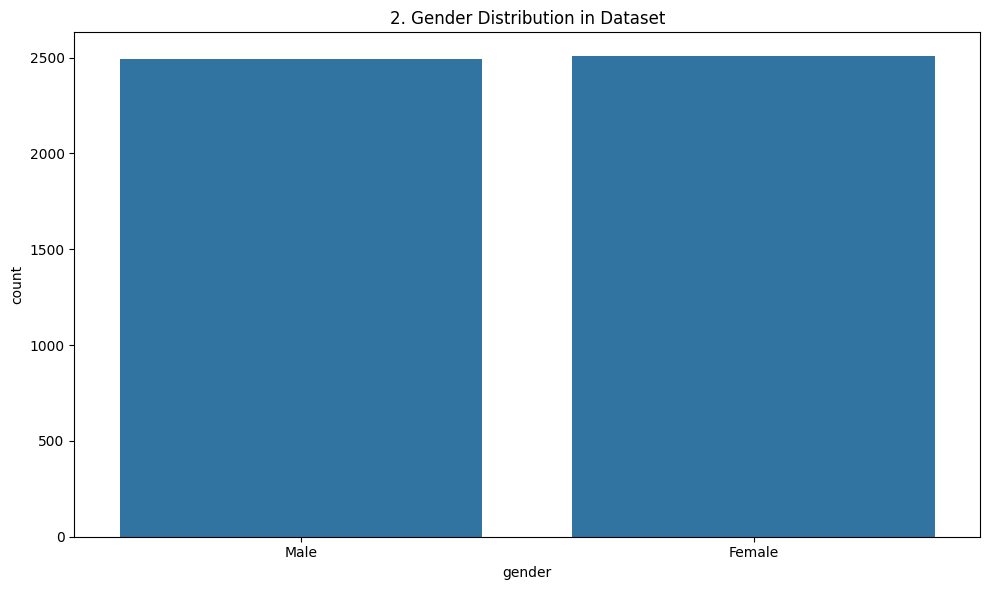

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df)
plt.title(f'{plot_no}. Gender Distribution in Dataset')
show_fig()
plot_no += 1

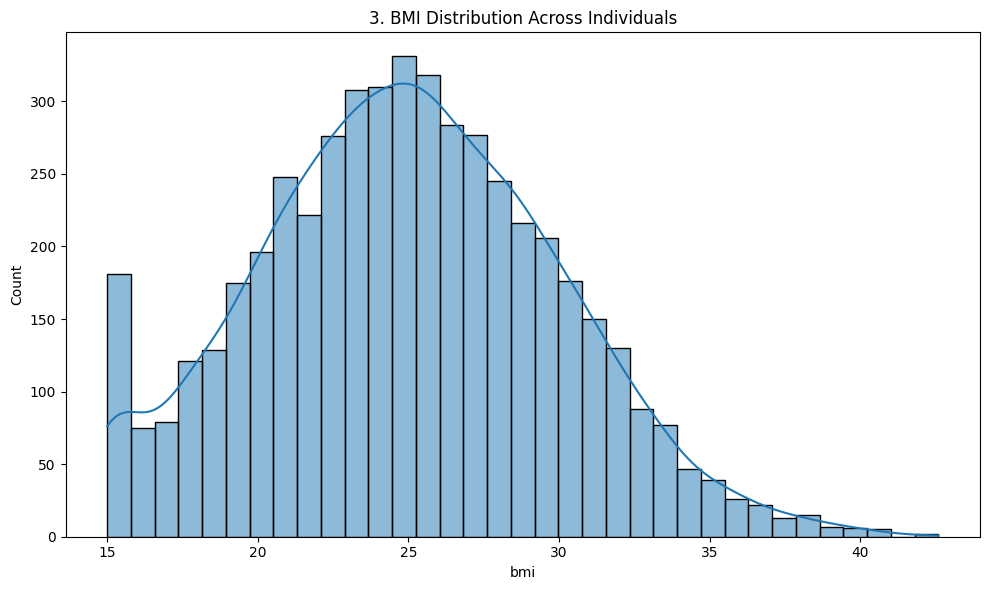

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['bmi'], kde=True)
plt.title(f'{plot_no}. BMI Distribution Across Individuals')
show_fig()
plot_no += 1

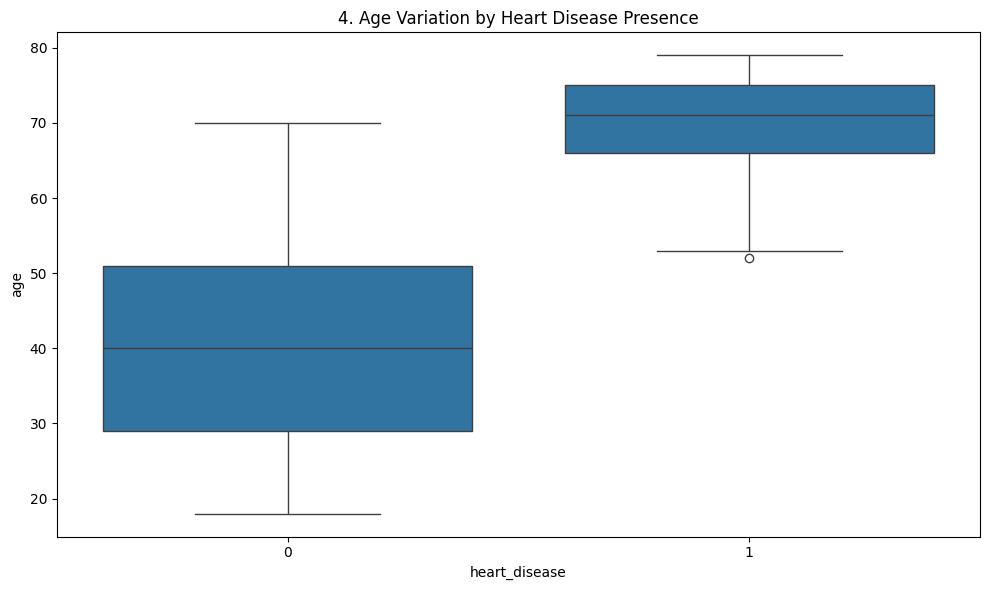

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title(f'{plot_no}. Age Variation by Heart Disease Presence')
show_fig()
plot_no += 1

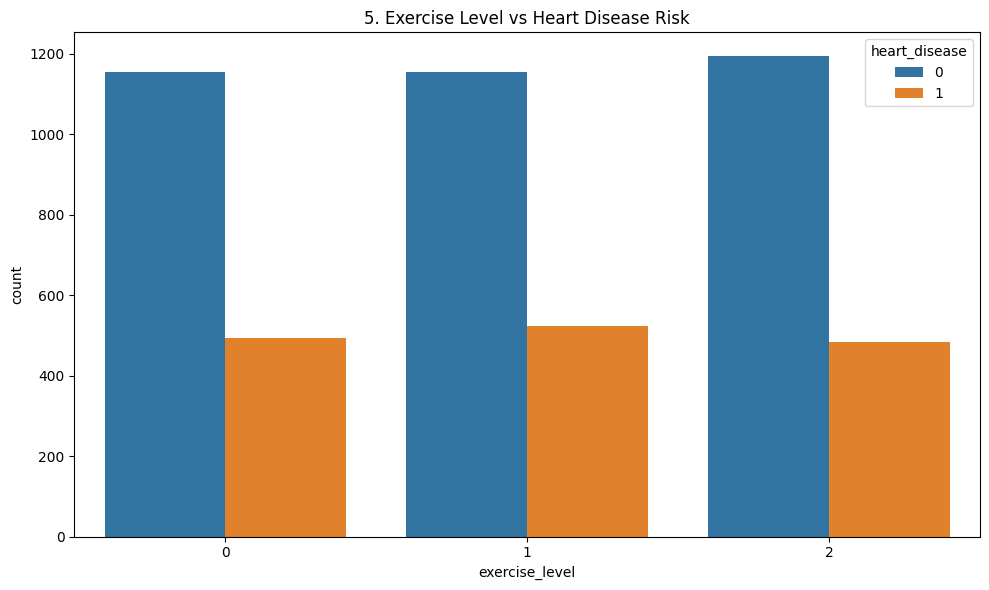

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='exercise_level', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Exercise Level vs Heart Disease Risk')
show_fig()
plot_no += 1

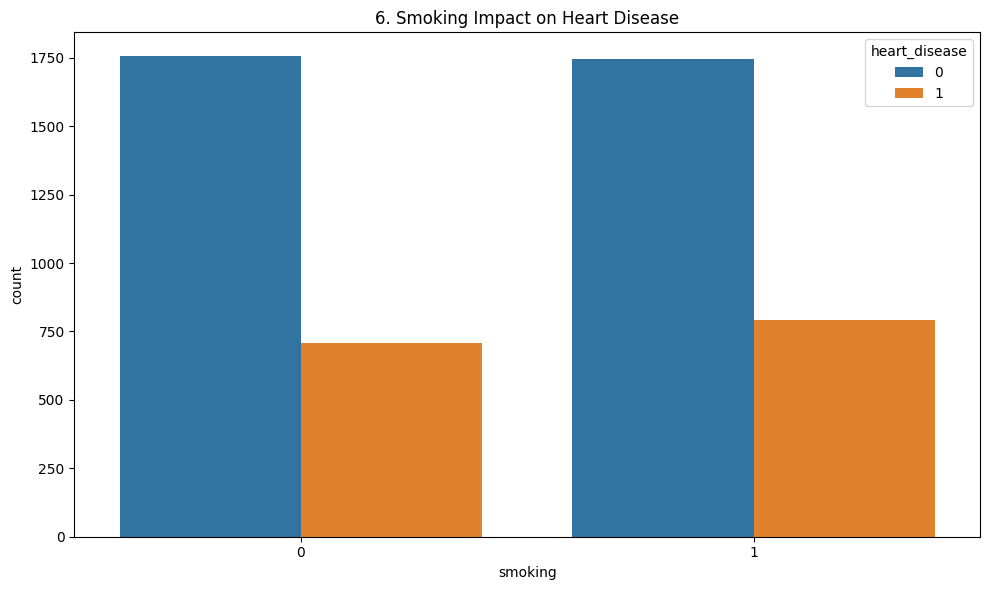

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='smoking', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Smoking Impact on Heart Disease')
show_fig()
plot_no += 1

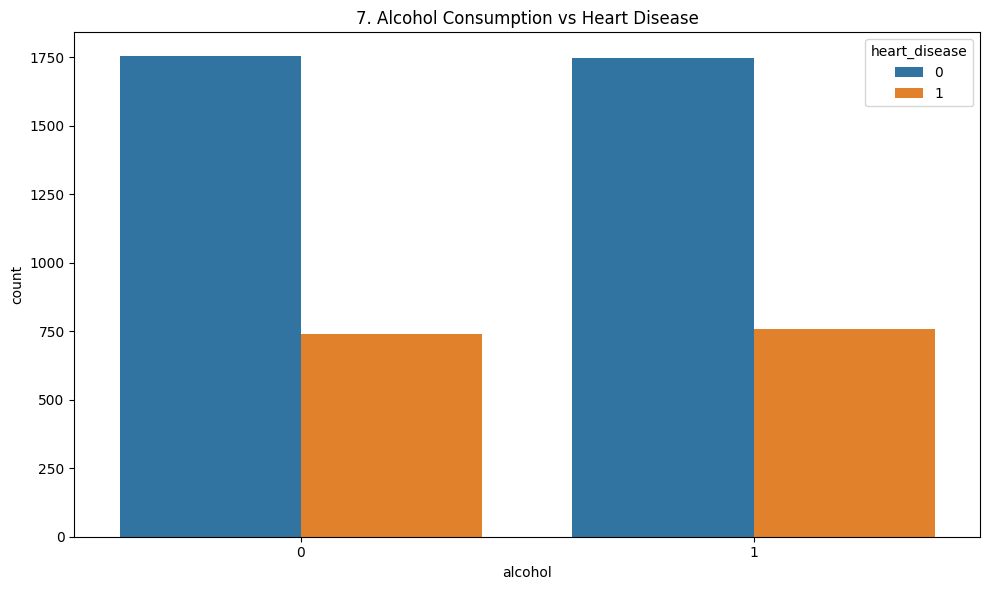

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='alcohol', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Alcohol Consumption vs Heart Disease')
show_fig()
plot_no += 1

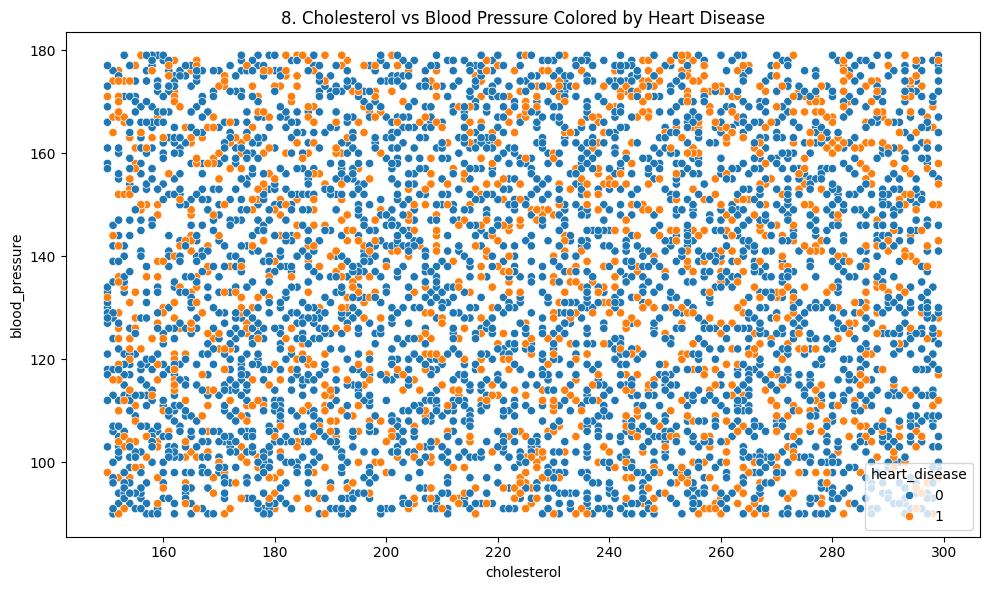

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='cholesterol', y='blood_pressure', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Cholesterol vs Blood Pressure Colored by Heart Disease')
show_fig()
plot_no += 1

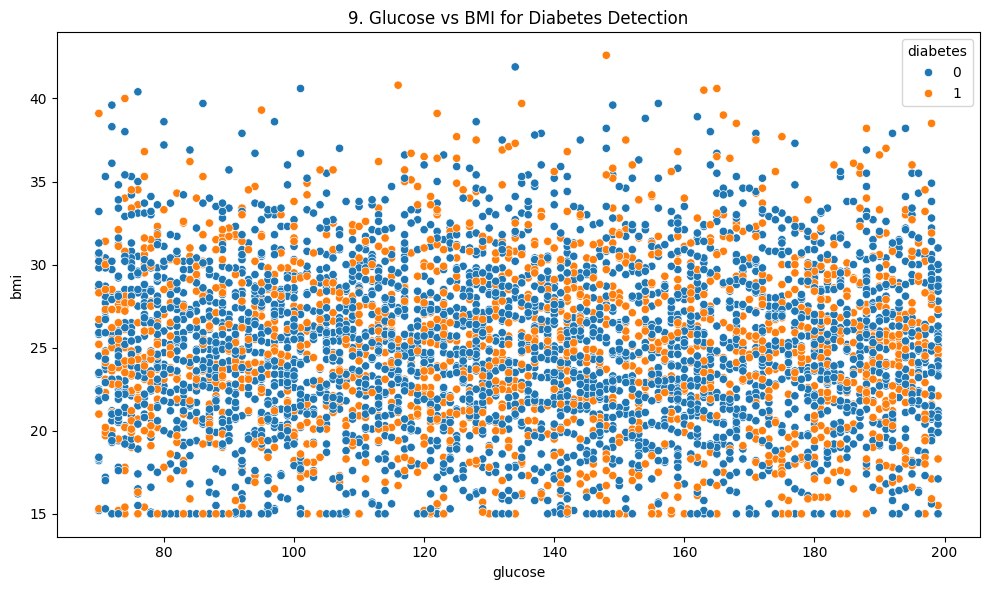

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='glucose', y='bmi', hue='diabetes', data=df)
plt.title(f'{plot_no}. Glucose vs BMI for Diabetes Detection')
show_fig()
plot_no += 1

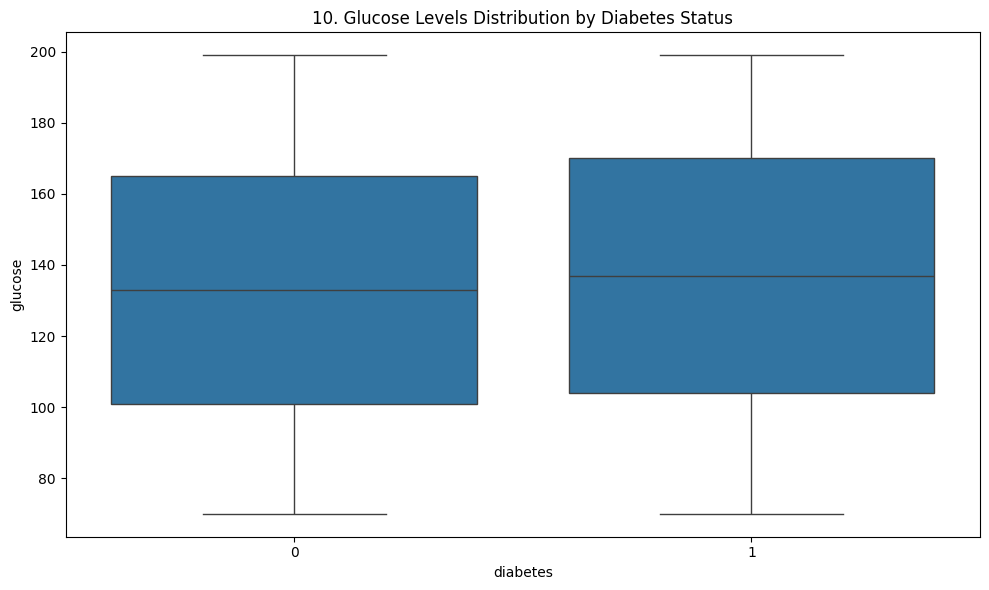

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes', y='glucose', data=df)
plt.title(f'{plot_no}. Glucose Levels Distribution by Diabetes Status')
show_fig()
plot_no += 1

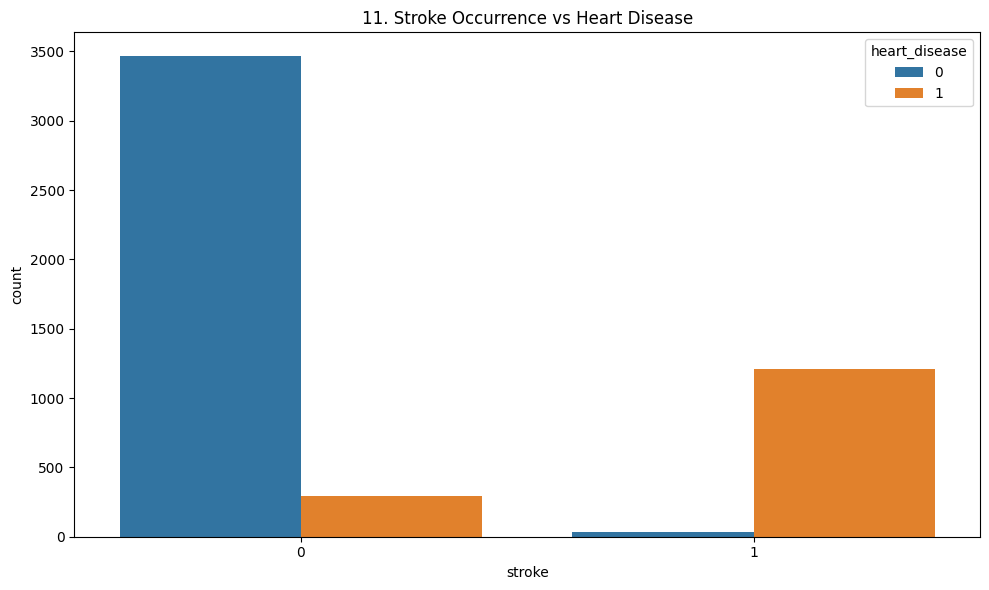

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='stroke', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Stroke Occurrence vs Heart Disease')
show_fig()
plot_no += 1

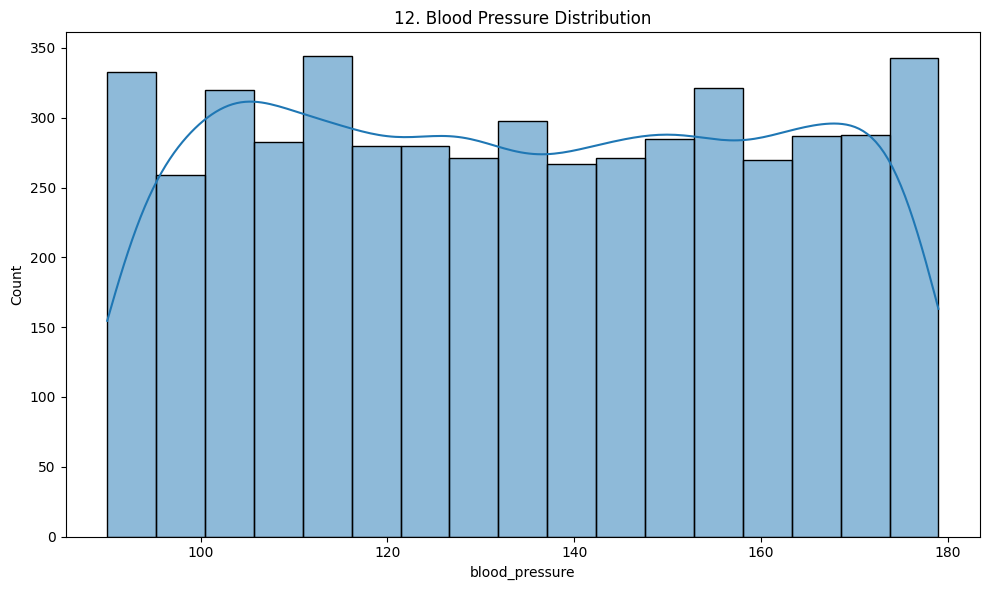

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['blood_pressure'], kde=True)
plt.title(f'{plot_no}. Blood Pressure Distribution')
show_fig()
plot_no += 1

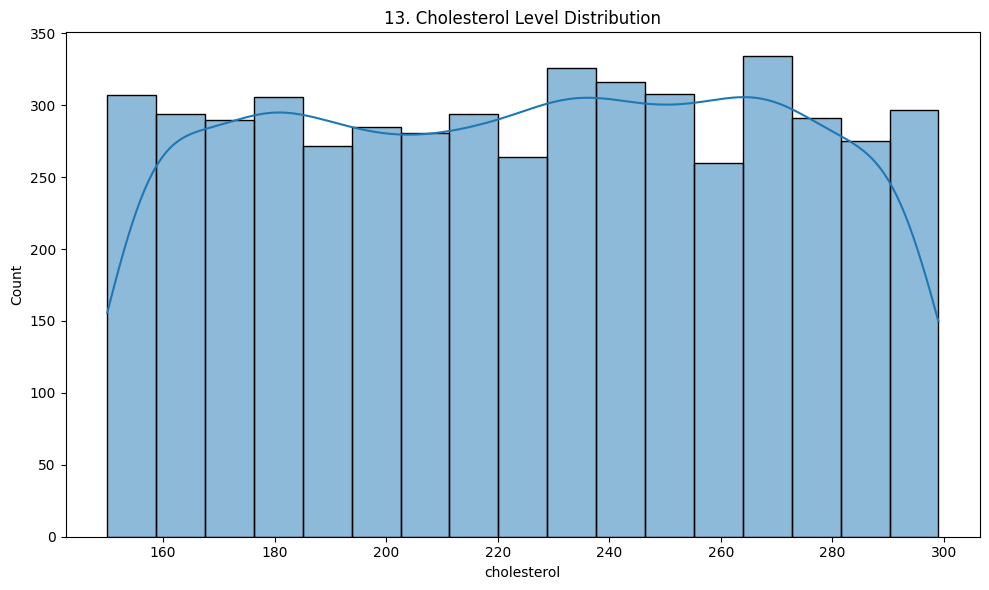

In [25]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['cholesterol'], kde=True)
plt.title(f'{plot_no}. Cholesterol Level Distribution')
show_fig()
plot_no += 1

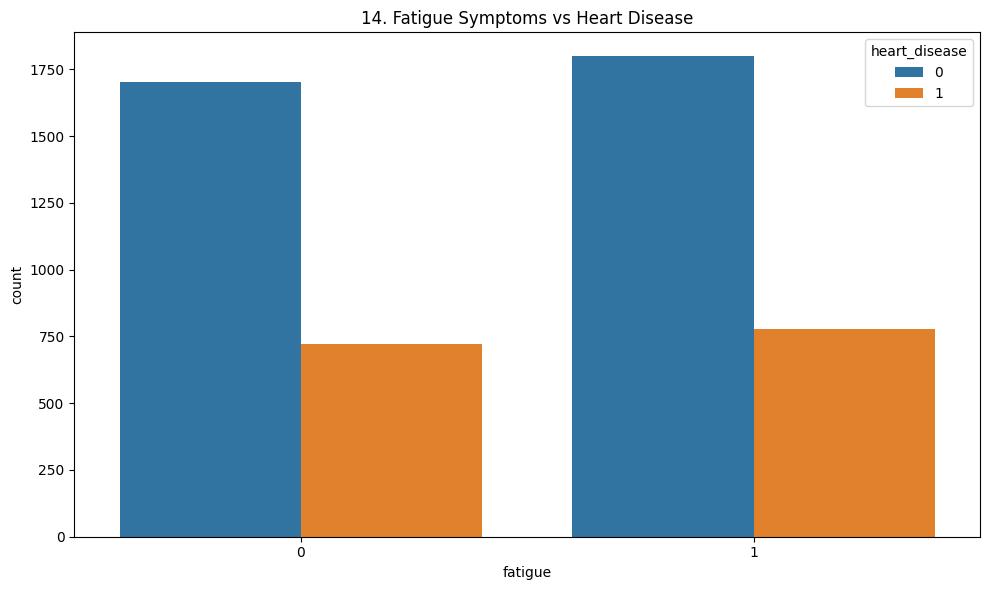

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='fatigue', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Fatigue Symptoms vs Heart Disease')
show_fig()
plot_no += 1

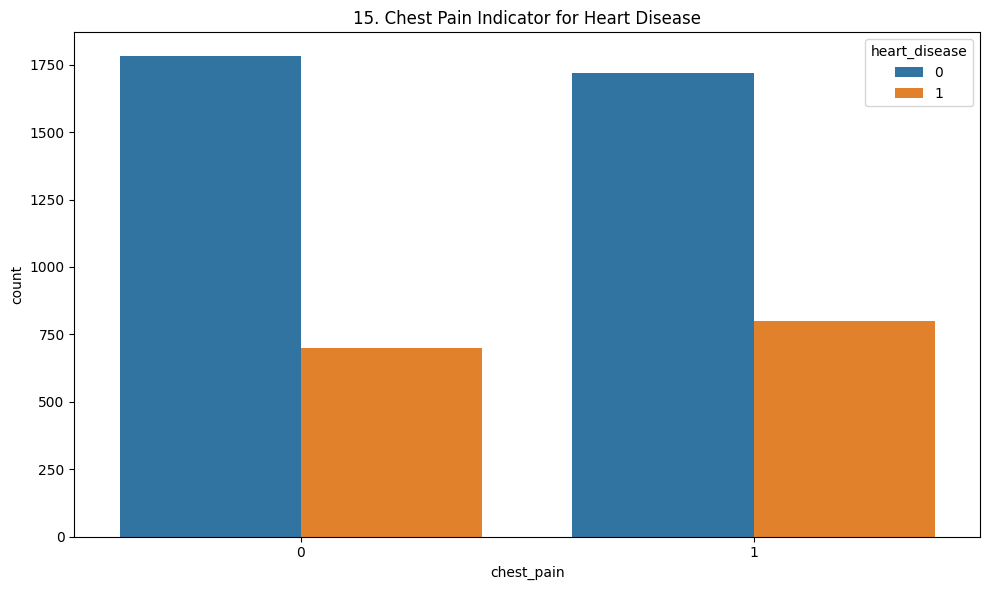

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='chest_pain', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Chest Pain Indicator for Heart Disease')
show_fig()
plot_no += 1

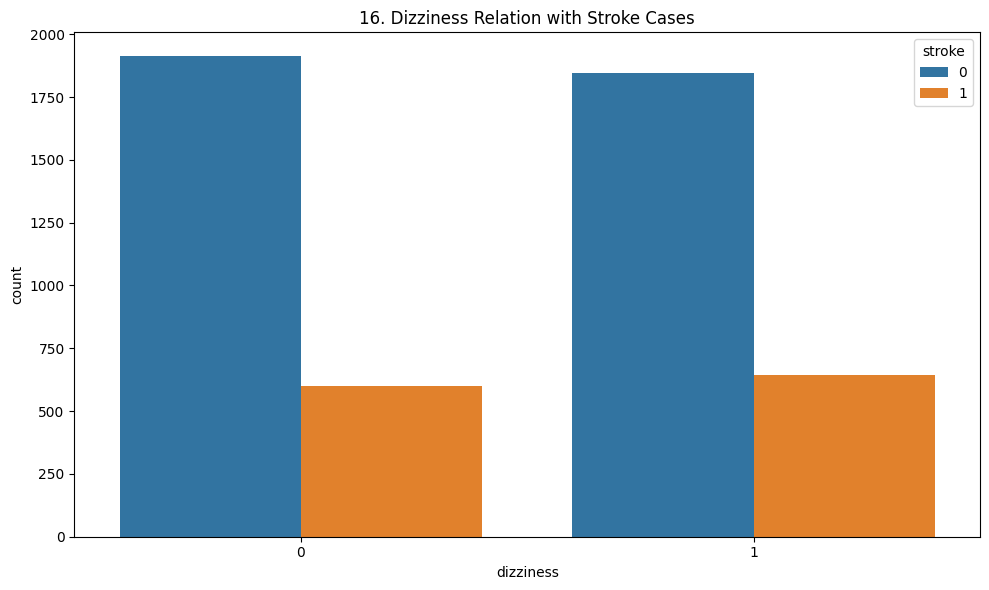

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='dizziness', hue='stroke', data=df)
plt.title(f'{plot_no}. Dizziness Relation with Stroke Cases')
show_fig()
plot_no += 1

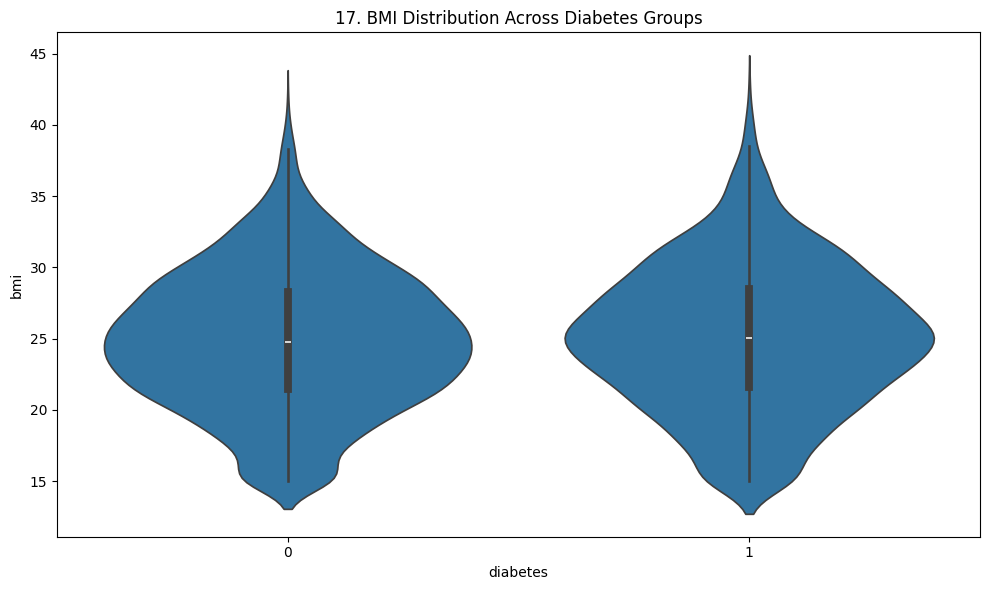

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='diabetes', y='bmi', data=df)
plt.title(f'{plot_no}. BMI Distribution Across Diabetes Groups')
show_fig()
plot_no += 1

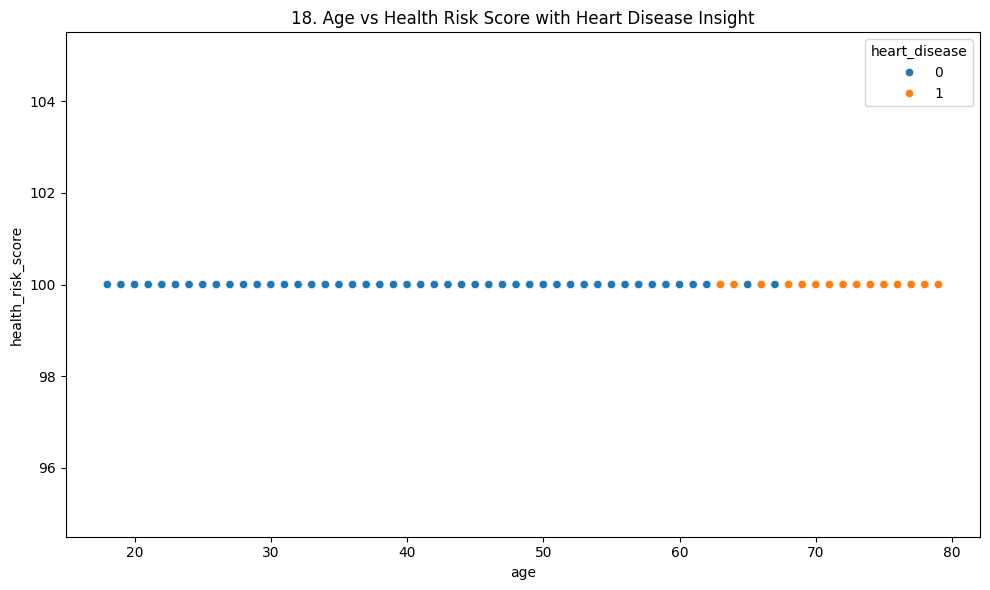

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='health_risk_score', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Age vs Health Risk Score with Heart Disease Insight')
show_fig()
plot_no += 1

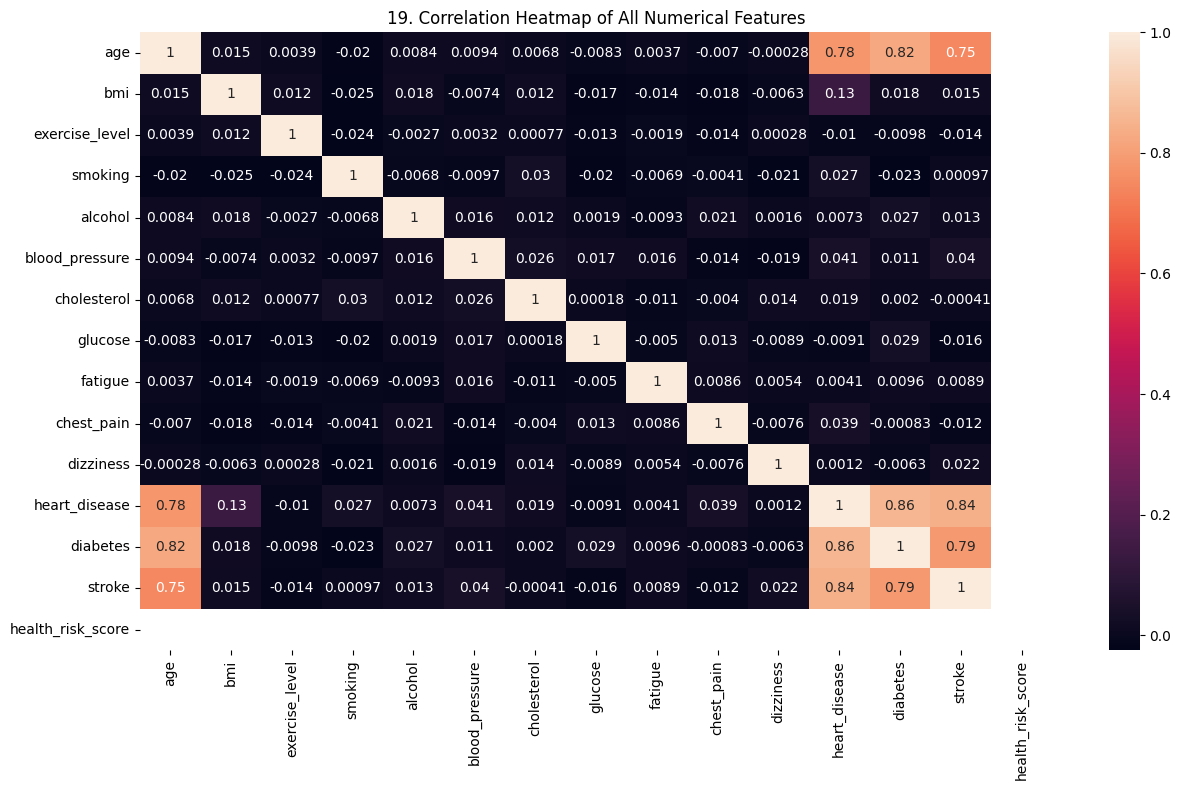

In [31]:
fig = plt.figure(figsize=(13, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## convert categorical column to numeric

In [32]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

## select features and target

In [33]:
X = df.drop(columns=['heart_disease','health_risk_score'])
y = df['heart_disease']

## split dataset into train and test

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train logistic regression model

In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [37]:
y_pred = model.predict(X_test)

## print accuracy score

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.988


## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

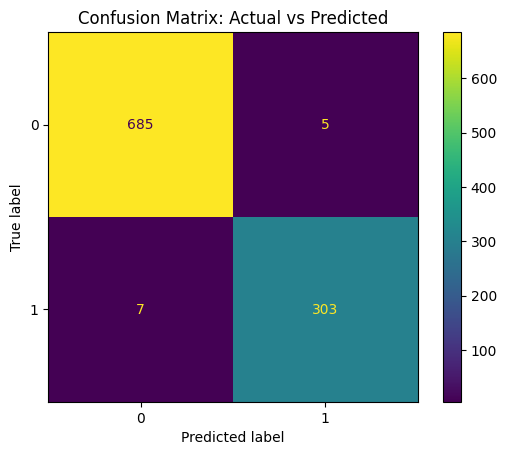

In [39]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()